   Country     Period  Economic_Openness_Pct  FDI_to_GDP_Pct  GDP_Growth_Pct
60     VNM  1990-1999              82.708515        6.808756        7.419015
61     VNM  2000-2008             130.596187        4.963133        6.783665
62     VNM  2009-2019             140.372504        4.905074        6.468748
63     VNM  2020-2024             174.351082        4.331799        5.222571


<Axes: title={'center': 'Độ mở kinh tế: VNM vs Các nước cạnh tranh FDI'}, xlabel='Year'>

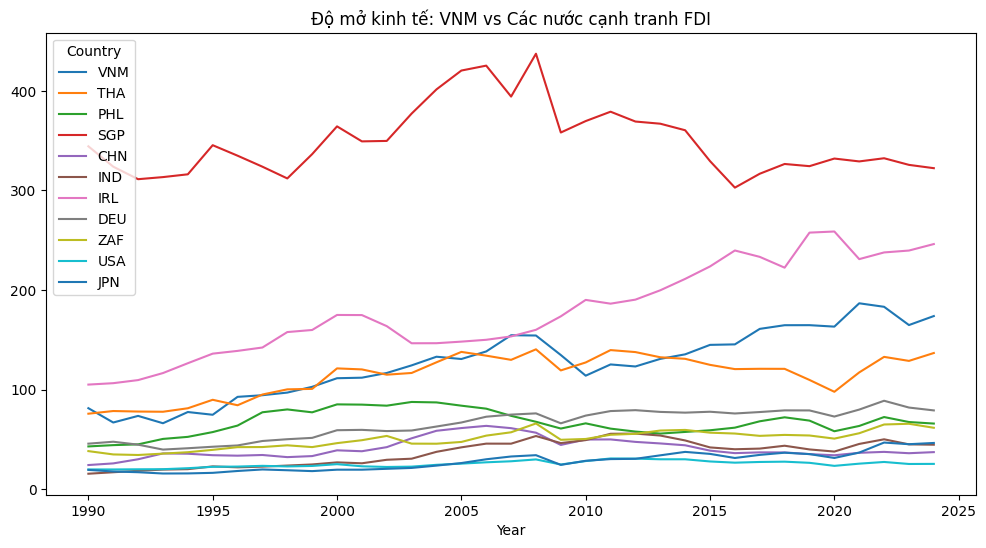

In [20]:
import pandas as pd
import numpy as np

# 1. Load dữ liệu
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# 2. Tạo cột Period
conditions = [
    (df['Year'] >= 1990) & (df['Year'] <= 1999),
    (df['Year'] >= 2000) & (df['Year'] <= 2008),
    (df['Year'] >= 2009) & (df['Year'] <= 2019),
    (df['Year'] >= 2020) & (df['Year'] <= 2024)
]
choices = ['1990-1999', '2000-2008', '2009-2019', '2020-2024']
df['Period'] = np.select(conditions, choices, default='Unknown')

# Tính trung bình các chỉ số cốt lõi theo Quốc gia và Giai đoạn
agg_df = df.groupby(['Country', 'Period'])[['Economic_Openness_Pct', 'FDI_to_GDP_Pct', 'GDP_Growth_Pct']].mean().reset_index()

# Xem thử sự thay đổi của Việt Nam qua các thời kỳ
vnm_data = agg_df[agg_df['Country'] == 'VNM']
print(vnm_data)

# Pivot table để so sánh Economic Openness giữa các nước trong cùng 1 giai đoạn
pivot_openness = df.pivot_table(index='Year', columns='Country', values='Economic_Openness_Pct')

# Vẽ biểu đồ so sánh độ mở của VNM, CHN, THA, MEX
pivot_openness[['VNM', 'THA', 'PHL', 'SGP', 'CHN', 'IND',
     'IRL', 'DEU', 'ZAF', 'USA', 'JPN']].plot(kind='line', figsize=(12, 6), title='Độ mở kinh tế: VNM vs Các nước cạnh tranh FDI')


### Phân tích sâu hơn về Việt Nam


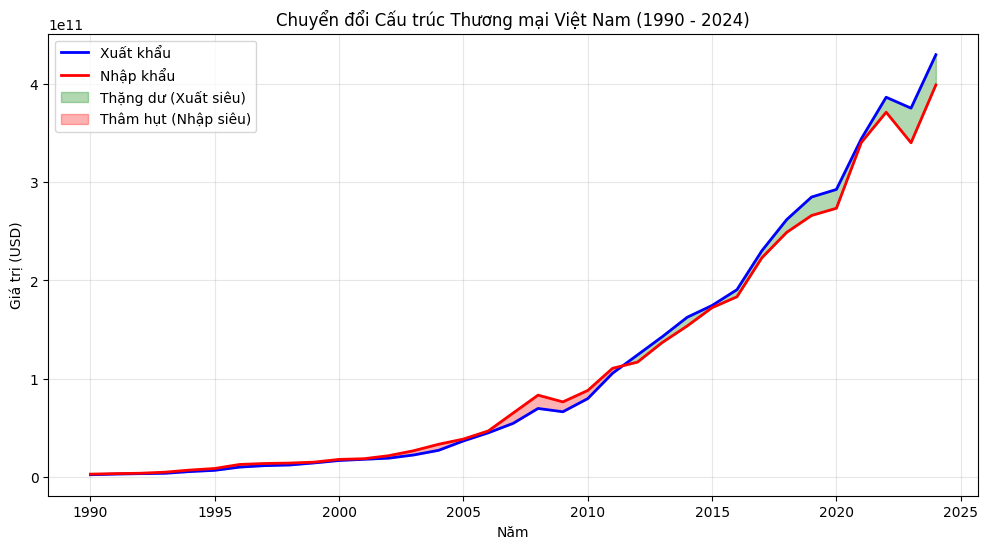

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Lọc dữ liệu riêng cho Việt Nam
vnm_df = df[df['Country'] == 'VNM'].sort_values('Year')

plt.figure(figsize=(12, 6))

# Vẽ đường Xuất khẩu và Nhập khẩu
plt.plot(vnm_df['Year'], vnm_df['Exports_USD'], label='Xuất khẩu', color='blue', linewidth=2)
plt.plot(vnm_df['Year'], vnm_df['Imports_USD'], label='Nhập khẩu', color='red', linewidth=2)

# Tô màu Cán cân thương mại: Xanh nếu Xuất > Nhập, Đỏ nếu Nhập > Xuất
plt.fill_between(vnm_df['Year'], vnm_df['Exports_USD'], vnm_df['Imports_USD'], 
                 where=(vnm_df['Exports_USD'] >= vnm_df['Imports_USD']), interpolate=True, color='green', alpha=0.3, label='Thặng dư (Xuất siêu)')
plt.fill_between(vnm_df['Year'], vnm_df['Exports_USD'], vnm_df['Imports_USD'], 
                 where=(vnm_df['Exports_USD'] < vnm_df['Imports_USD']), interpolate=True, color='red', alpha=0.3, label='Thâm hụt (Nhập siêu)')

plt.title('Chuyển đổi Cấu trúc Thương mại Việt Nam (1990 - 2024)')
plt.xlabel('Năm')
plt.ylabel('Giá trị (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dữ liệu chuẩn từ năm 2000:
     Year  GDP_Current_USD       GNI_USD  GDP_GNI_Gap_Pct
535  2000     3.117252e+10  3.072594e+10         1.432595
536  2001     3.268520e+10  3.224785e+10         1.338057
537  2002     3.506411e+10  3.449432e+10         1.624975
538  2003     3.955251e+10  3.892355e+10         1.590205
539  2004     4.542785e+10  4.457678e+10         1.873461


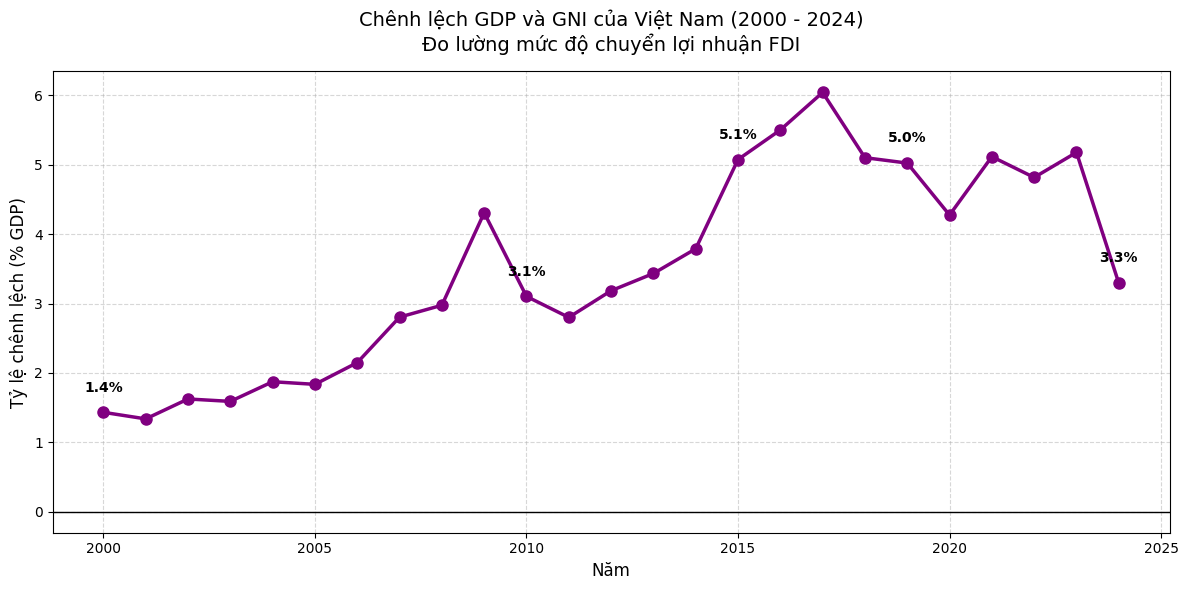

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc lại dữ liệu (giả sử bạn đang ở cùng thư mục với file)
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# 2. Lọc riêng Việt Nam
vnm_df = df[df['Country'] == 'VNM'].copy()

# 3. Tính toán cột Chênh lệch (% GDP)
vnm_df['GDP_GNI_Gap_Pct'] = ((vnm_df['GDP_Current_USD'] - vnm_df['GNI_USD']) / vnm_df['GDP_Current_USD']) * 100

# 4. BỘ LỌC CỐT LÕI: Chỉ lấy dữ liệu từ năm 2000 trở đi và loại bỏ các Outliers
vnm_df_clean = vnm_df[(vnm_df['Year'] >= 2000) & (vnm_df['GDP_GNI_Gap_Pct'] > -10) & (vnm_df['GDP_GNI_Gap_Pct'] < 20)]

# Xem thử 5 dòng đầu tiên sau khi lọc để xác nhận
print("Dữ liệu chuẩn từ năm 2000:")
print(vnm_df_clean[['Year', 'GDP_Current_USD', 'GNI_USD', 'GDP_GNI_Gap_Pct']].head())

# 5. Vẽ biểu đồ chuẩn
plt.figure(figsize=(12, 6))
plt.plot(vnm_df_clean['Year'], vnm_df_clean['GDP_GNI_Gap_Pct'], 
         marker='o', color='purple', linewidth=2.5, markersize=8)

# Định dạng biểu đồ
plt.title('Chênh lệch GDP và GNI của Việt Nam (2000 - 2024)\nĐo lường mức độ chuyển lợi nhuận FDI', fontsize=14, pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tỷ lệ chênh lệch (% GDP)', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.5)

# Gắn nhãn các năm đột biến
for year in [2000, 2010, 2015, 2019, 2024]:
    if year in vnm_df_clean['Year'].values:
        val = vnm_df_clean[vnm_df_clean['Year'] == year]['GDP_GNI_Gap_Pct'].values[0]
        plt.text(year, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

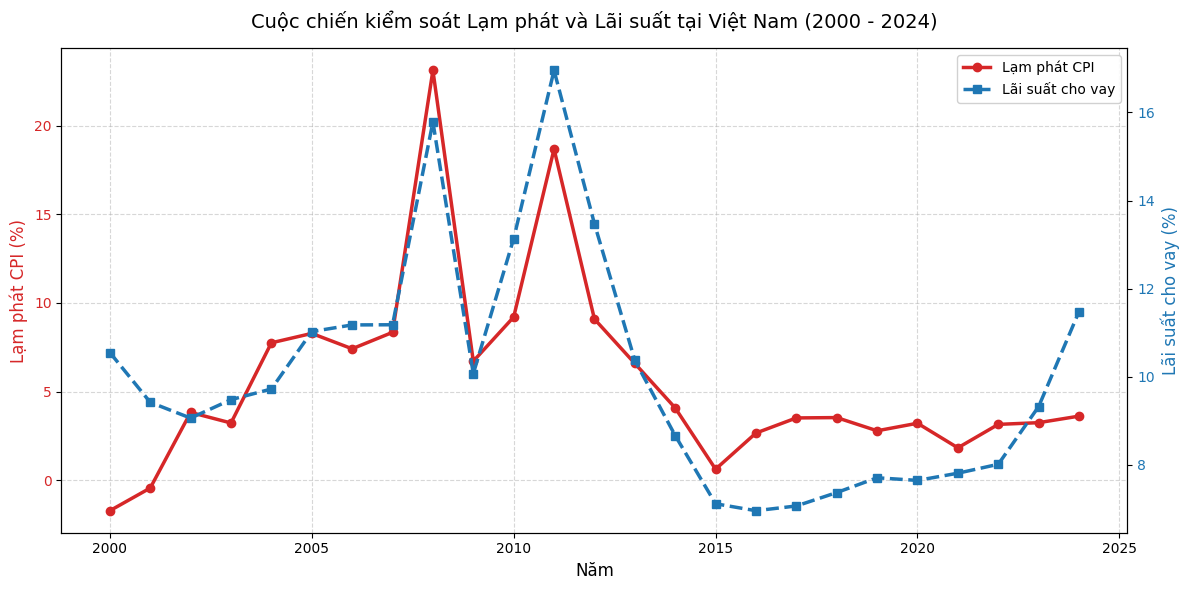

In [32]:
import matplotlib.pyplot as plt

# 1. BỘ LỌC: Chỉ lấy dữ liệu từ năm 2000 trở đi để biểu đồ không bị nhiễu
vnm_df_clean = vnm_df[vnm_df['Year'] >= 2000].copy()

# 2. Khởi tạo biểu đồ
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục 1: Lạm phát (Màu đỏ)
color1 = 'tab:red'
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Lạm phát CPI (%)', color=color1, fontsize=12)
line1 = ax1.plot(vnm_df_clean['Year'], vnm_df_clean['Inflation_CPI_Pct'], 
                 color=color1, linewidth=2.5, marker='o', label='Lạm phát CPI')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5) # Thêm lưới cho dễ nhìn

# Trục 2: Lãi suất cho vay (Màu xanh)
ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('Lãi suất cho vay (%)', color=color2, fontsize=12)  
line2 = ax2.plot(vnm_df_clean['Year'], vnm_df_clean['Lending_Interest_Rate_Pct'], 
                 color=color2, linestyle='--', linewidth=2.5, marker='s', label='Lãi suất cho vay')
ax2.tick_params(axis='y', labelcolor=color2)

# 3. Gộp chung Legend của cả 2 trục
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', framealpha=0.9)

# 4. Tiêu đề và định dạng
plt.title('Cuộc chiến kiểm soát Lạm phát và Lãi suất tại Việt Nam (2000 - 2024)', fontsize=14, pad=15)
fig.tight_layout() 
plt.show()

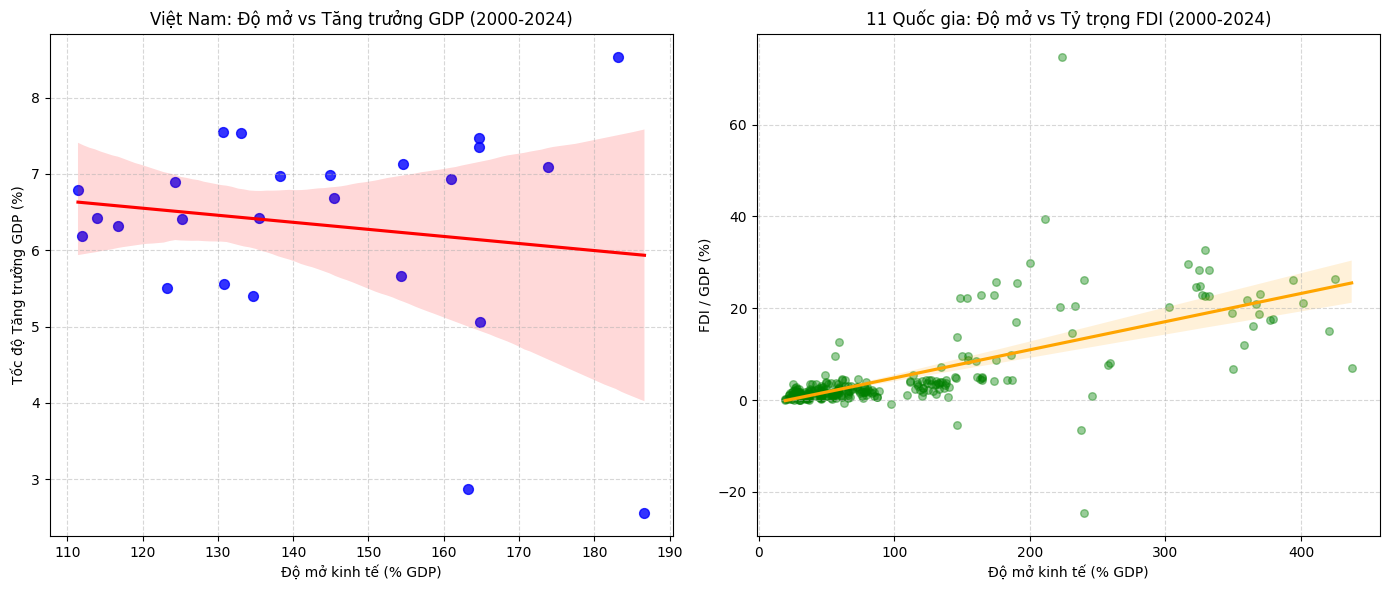

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# 2. Lọc dữ liệu Việt Nam và 11 quốc gia trọng tâm từ năm 2000
vnm_df = df[(df['Country'] == 'VNM') & (df['Year'] >= 2000)].copy()
core_countries = ['VNM', 'THA', 'PHL', 'SGP', 'CHN', 'IND', 'IRL', 'DEU', 'ZAF', 'USA', 'JPN']
core_df = df[(df['Country'].isin(core_countries)) & (df['Year'] >= 2000)]

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 6))

# Biểu đồ trái: Việt Nam (Thể hiện quy luật số lớn, đường xu hướng đi ngang/chơi vơi)
plt.subplot(1, 2, 1)
sns.regplot(data=vnm_df, x='Economic_Openness_Pct', y='GDP_Growth_Pct', 
            color='blue', scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Việt Nam: Độ mở vs Tăng trưởng GDP (2000-2024)', fontsize=12)
plt.xlabel('Độ mở kinh tế (% GDP)')
plt.ylabel('Tốc độ Tăng trưởng GDP (%)')
plt.grid(True, linestyle='--', alpha=0.5)

# Biểu đồ phải: 11 Quốc gia (Độ mở vs FDI - Thể hiện sức hút dòng vốn)
plt.subplot(1, 2, 2)
sns.regplot(data=core_df, x='Economic_Openness_Pct', y='FDI_to_GDP_Pct', 
            color='green', scatter_kws={'alpha':0.4, 's': 30}, line_kws={'color': 'orange'})
plt.title('11 Quốc gia: Độ mở vs Tỷ trọng FDI (2000-2024)', fontsize=12)
plt.xlabel('Độ mở kinh tế (% GDP)')
plt.ylabel('FDI / GDP (%)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np

# 1. Định nghĩa các năm khủng hoảng toàn cầu
crisis_years = [1997, 1998, 2008, 2009, 2020, 2021, 2022]
df['Is_Crisis'] = df['Year'].apply(lambda x: 'Crisis' if x in crisis_years else 'Normal')

# 2. Tính độ biến động (Standard Deviation) của Tăng trưởng và Lạm phát
vulnerability_df = df.groupby(['Country', 'Is_Crisis'])[['GDP_Growth_Pct', 'Inflation_CPI_Pct']].std().reset_index()

# 3. So sánh Việt Nam với một nước có độ mở thấp (ví dụ: ZAF - Nam Phi)
compare_vuln = vulnerability_df[vulnerability_df['Country'].isin(['VNM', 'SGP','USA','ZAF'])]
print(compare_vuln)

   Country Is_Crisis  GDP_Growth_Pct  Inflation_CPI_Pct
24     SGP    Crisis        5.114108           2.857930
25     SGP    Normal        3.446260           1.583522
28     USA    Crisis        3.428125           2.754262
29     USA    Normal        1.012814           1.036421
30     VNM    Crisis        2.308004           7.415383
31     VNM    Normal        1.215875           3.747938
32     ZAF    Crisis        3.677266           2.259967
33     ZAF    Normal        1.940288           3.550631


In [42]:
# 1. Tỷ lệ bù đắp xuất nhập khẩu (Export Coverage Ratio)
# > 1: Xuất siêu (An toàn ngoại hối) | < 1: Nhập siêu
df['Export_Coverage_Ratio'] = df['Exports_USD'] / df['Imports_USD']

# 2. Tỷ lệ giữ lại giá trị quốc gia (GNI/GDP Ratio)
df['GNI_GDP_Ratio'] = df['GNI_USD'] / df['GDP_Current_USD']

# 3. Tăng trưởng thực tế loại bỏ lạm phát (Real Growth Proxy)
# Công thức xấp xỉ: Tăng trưởng danh nghĩa - Lạm phát
df['Real_Wealth_Growth'] = df['GDP_Growth_Pct'] - df['Inflation_CPI_Pct']

# Kiểm tra dữ liệu của Việt Nam sau khi thêm biến
print(df[df['Country'] == 'VNM'][['Year', 'Export_Coverage_Ratio', 'GNI_GDP_Ratio', 'Real_Wealth_Growth']])

     Year  Export_Coverage_Ratio  GNI_GDP_Ratio  Real_Wealth_Growth
525  1990               0.795957       0.936337           -0.510264
526  1991               0.857991       0.946719            0.349662
527  1992               0.894783       0.965847            3.034866
528  1993               0.766156       0.961892            2.461549
529  1994               0.782629       0.974699            3.227799
530  1995               0.782966       0.999061            3.929298
531  1996               0.788400       0.991244            3.665017
532  1997               0.841163       0.983984            4.942558
533  1998               0.859938       0.977339           -1.501743
534  1999               0.945951       0.981875            0.656485
535  2000               0.937837       0.985674            8.497654
536  2001               0.967799       0.986619            6.624438
537  2002               0.883492       0.983750            2.489993
538  2003               0.837684       0.984098 

In [45]:
import plotly.graph_objects as go
import numpy as np

# 1. Lấy danh sách các quốc gia duy nhất (sắp xếp theo Alphabet)
countries = sorted(df['Country'].unique())

fig = go.Figure()

# 2. Vòng lặp: Thêm toàn bộ các traces (đường/cột) cho TẤT CẢ quốc gia vào biểu đồ
for country in countries:
    country_df = df[df['Country'] == country].sort_values('Year')
    
    # Trace 1: Cột Cán cân thương mại
    fig.add_trace(go.Bar(
        x=country_df['Year'],
        y=country_df['Trade_Balance_USD'],
        name=f'Cán cân thương mại',
        marker_color=np.where(country_df['Trade_Balance_USD'] < 0, 'red', 'green'),
        visible=(country == 'VNM') # Mặc định chỉ hiển thị VNM ban đầu
    ))

    # Trace 2: Đường Độ mở kinh tế
    fig.add_trace(go.Scatter(
        x=country_df['Year'],
        y=country_df['Economic_Openness_Pct'],
        name=f'Độ mở kinh tế',
        yaxis='y2',
        line=dict(color='blue', width=3),
        visible=(country == 'VNM') # Mặc định chỉ hiển thị VNM ban đầu
    ))

# 3. Xây dựng logic cho Menu Dropdown
buttons = []
for i, country in enumerate(countries):
    # Mỗi quốc gia có 2 traces (Bar và Scatter), tạo mảng boolean để bật đúng 2 traces đó
    visibility = [False] * (len(countries) * 2)
    visibility[i*2] = True      # Bật Bar chart của quốc gia thứ i
    visibility[i*2 + 1] = True  # Bật Scatter chart của quốc gia thứ i
    
    button = dict(
        label=country,
        method="update",
        args=[
            {"visible": visibility}, # Hành động 1: Cập nhật dữ liệu hiển thị
            {"title": f"{country}: Chuyển đổi mô hình Thương mại (1990 - 2024)"} # Hành động 2: Đổi tiêu đề
        ]
    )
    buttons.append(button)

# 4. Cập nhật Layout với Dropdown và Trục Y kép
# Đặt chỉ mục mặc định của Dropdown vào 'VNM'
default_index = countries.index('VNM') if 'VNM' in countries else 0

fig.update_layout(
    updatemenus=[
        dict(
            active=default_index,
            buttons=buttons,
            x=1.1, # Đẩy menu ra ngoài góc phải
            y=1.15,
            xanchor="right",
            yanchor="top"
        )
    ],
    title='VNM: Chuyển đổi mô hình Thương mại (1990 - 2024)',
    yaxis=dict(title='Cán cân thương mại (USD)'),
    yaxis2=dict(title='Độ mở kinh tế (% GDP)', overlaying='y', side='right'),
    barmode='group',
    height=600,
    margin=dict(r=100) # Mở rộng lề phải để không bị cắt chữ ở trục Y2
)

fig.show()